# Trabajo Práctico Final - Ciencia de Datos
## Análisis de Datos de Ventas en Comercio Electrónico

**Dataset:** Olist Brazilian E-Commerce Public Dataset.

**Objetivo:** analizar ventas reales de una plataforma de comercio electrónico aplicando análisis estadístico, probabilidad, probabilidad condicional, probabilidad total y modelos Normal, Binomial y Poisson.
Si el archivo `.zip` no está cargado, subilo desde el panel de archivos o ejecutá la celda de carga.

## 1. Preparación del entorno
Importamos librerías y buscamos el archivo ZIP del dataset.

In [29]:
import os, zipfile, json, math, warnings, shutil
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_DIR = '/content/olist' if os.path.exists('/content') else './olist'
os.makedirs(DATA_DIR, exist_ok=True)

# Buscar el zip en la carpeta del proyecto o rutas comunes
posibles_zips = [
    os.path.join(DATA_DIR, 'archive.zip'),
    os.path.join(DATA_DIR, 'archive(1).zip'),
    '/content/archive(1).zip',
    '/content/archive.zip',
    'archive(1).zip',
    'archive.zip'
]

ZIP_PATH = next((p for p in posibles_zips if os.path.exists(p)), None)

if ZIP_PATH is None:
    try:
        from google.colab import files
        print('Subí el archivo archive(1).zip del dataset Olist.')
        uploaded = files.upload()
        if uploaded:
            temp_path = list(uploaded.keys())[0]
            ZIP_PATH = os.path.join(DATA_DIR, temp_path)
            # Movemos el archivo subido a la carpeta de datos para persistencia
            shutil.move(temp_path, ZIP_PATH)
    except Exception as e:
        raise FileNotFoundError('No se encontró el ZIP del dataset. Subilo al entorno y volvé a correr la celda.')

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_DIR)

print('Dataset extraído y guardado en:', DATA_DIR)
print('Contenido:', os.listdir(DATA_DIR))

Dataset extraído y guardado en: /content/olist
Contenido: ['olist_order_payments_dataset.csv', 'olist_geolocation_dataset.csv', 'archive.zip', 'olist_order_reviews_dataset.csv', 'olist_sellers_dataset.csv', 'olist_customers_dataset.csv', 'product_category_name_translation.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_orders_dataset.csv']


## 2. Carga de tablas
El dataset viene separado en tablas: pedidos, productos, clientes, pagos, reseñas, vendedores e ítems de cada pedido.

In [30]:
import pandas as pd
import os
import zipfile

DATA_DIR = '/content/olist' if os.path.exists('/content') else './olist'

if not os.path.exists(f'{DATA_DIR}/olist_orders_dataset.csv'):
    print("Dataset files not found in DATA_DIR. Attempting to re-extract from zip.")
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_paths_to_check = ['/content/archive(1).zip', '/content/archive.zip', 'archive(1).zip', 'archive.zip']
    found_zip_path = next((p for p in zip_paths_to_check if os.path.exists(p)), None)
    if found_zip_path:
        with zipfile.ZipFile(found_zip_path, 'r') as z:
            z.extractall(DATA_DIR)
    else:
        raise FileNotFoundError("Dataset zip file not found.")

orders = pd.read_csv(f'{DATA_DIR}/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])
items = pd.read_csv(f'{DATA_DIR}/olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])
payments = pd.read_csv(f'{DATA_DIR}/olist_order_payments_dataset.csv')
reviews = pd.read_csv(f'{DATA_DIR}/olist_order_reviews_dataset.csv', parse_dates=['review_creation_date', 'review_answer_timestamp'])
products = pd.read_csv(f'{DATA_DIR}/olist_products_dataset.csv')
customers = pd.read_csv(f'{DATA_DIR}/olist_customers_dataset.csv')
sellers = pd.read_csv(f'{DATA_DIR}/olist_sellers_dataset.csv')
translation = pd.read_csv(f'{DATA_DIR}/product_category_name_translation.csv')
geolocation = pd.read_csv(f'{DATA_DIR}/olist_geolocation_dataset.csv')

resumen_tablas = pd.DataFrame({
    'tabla': ['orders', 'items', 'payments', 'reviews', 'products', 'customers', 'sellers', 'translation', 'geolocation'],
    'filas': [len(orders), len(items), len(payments), len(reviews), len(products), len(customers), len(sellers), len(translation), len(geolocation)]
})
display(resumen_tablas)

,tabla,filas
0,orders,99441
1,items,112650
2,payments,103886
3,reviews,99224
4,products,32951
5,customers,99441
6,sellers,3095
7,translation,71
8,geolocation,1000163


## 3. Limpieza y unión de datos
Nos quedamos con pedidos entregados, porque son los más adecuados para analizar ventas efectivas. Unimos pedidos, ítems y productos para obtener fecha, categoría, precio y flete.

In [31]:
# Traducción manual al español de las categorías principales usadas en el informe.
cat_es = {
    'bed_bath_table':'cama_mesa_baño', 'health_beauty':'salud_belleza', 'sports_leisure':'deporte_ocio',
    'furniture_decor':'muebles_decoración', 'computers_accessories':'computación_accesorios',
    'housewares':'artículos_hogar', 'watches_gifts':'relojes_regalos', 'telephony':'telefonía',
    'garden_tools':'herramientas_jardín', 'auto':'auto', 'cool_stuff':'cosas_copadas',
    'toys':'juguetes', 'baby':'bebé', 'perfumery':'perfumería', 'fashion_bags_accessories':'moda_bolsos_accesorios',
    'electronics':'electrónica', 'stationery':'librería', 'pet_shop':'mascotas', 'office_furniture':'muebles_oficina',
    'luggage_accessories':'equipaje_accesorios'
}

products = products.merge(translation, on='product_category_name', how='left')
products['category_en'] = products['product_category_name_english'].fillna(products['product_category_name']).fillna('sin_categoria')
products['categoria'] = products['category_en'].map(cat_es).fillna(products['category_en'])

orders_delivered = orders[orders['order_status'].eq('delivered')].copy()

order_items = (
    items.merge(orders_delivered[['order_id', 'customer_id', 'order_purchase_timestamp',
                                  'order_delivered_customer_date', 'order_estimated_delivery_date']],
                on='order_id', how='inner')
         .merge(products[['product_id', 'category_en', 'categoria']], on='product_id', how='left')
)

order_items['categoria'] = order_items['categoria'].fillna('sin_categoria')
order_items['fecha'] = order_items['order_purchase_timestamp'].dt.date
order_items['hora'] = order_items['order_purchase_timestamp'].dt.hour
order_items['dia_semana_num'] = order_items['order_purchase_timestamp'].dt.dayofweek

dias_es = {'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles','Thursday':'Jueves',
           'Friday':'Viernes','Saturday':'Sábado','Sunday':'Domingo'}
order_items['dia_semana'] = order_items['order_purchase_timestamp'].dt.day_name().map(dias_es)
order_items['mes'] = order_items['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Tabla a nivel pedido: cada fila representa una venta/pedido.
order_values = order_items.groupby('order_id', as_index=False).agg(
    ingresos_productos=('price', 'sum'),
    flete=('freight_value', 'sum'),
    cantidad_items=('order_item_id', 'count'),
    fecha_compra=('order_purchase_timestamp', 'min'),
    fecha_entrega=('order_delivered_customer_date', 'min'),
    fecha_estimada=('order_estimated_delivery_date', 'min')
)
order_values['ingreso_total'] = order_values['ingresos_productos'] + order_values['flete']
order_values['hora'] = order_values['fecha_compra'].dt.hour
order_values['dia_semana_num'] = order_values['fecha_compra'].dt.dayofweek
order_values['dia_semana'] = order_values['fecha_compra'].dt.day_name().map(dias_es)
order_values['mes'] = order_values['fecha_compra'].dt.to_period('M').astype(str)
order_values['entrega_tarde'] = order_values['fecha_entrega'] > order_values['fecha_estimada']

# Agregamos reseñas promedio por pedido.
order_values = order_values.merge(
    reviews.groupby('order_id', as_index=False).agg(review_score=('review_score','mean')),
    on='order_id', how='left'
)

# Período principal: 2017-01 a 2018-08. Evita meses incompletos de los extremos.
periodo = order_values[(order_values['fecha_compra'] >= '2017-01-01') & (order_values['fecha_compra'] < '2018-09-01')].copy()
items_periodo = order_items[(order_items['order_purchase_timestamp'] >= '2017-01-01') & (order_items['order_purchase_timestamp'] < '2018-09-01')].copy()

print('Pedidos entregados totales:', order_values['order_id'].nunique())
print('Ítems vendidos totales:', len(order_items))
print('Pedidos del período principal:', len(periodo))

Pedidos entregados totales: 96478
Ítems vendidos totales: 110197
Pedidos del período principal: 96211


## 4. Análisis estadístico general
Calculamos medidas de resumen: total de pedidos, ingresos, ticket promedio, mediana, cantidad media de ítems y nivel de satisfacción.

In [32]:
metricas = {
    'Pedidos entregados': order_values['order_id'].nunique(),
    'Ítems vendidos': len(order_items),
    'Productos únicos': order_items['product_id'].nunique(),
    'Categorías únicas': order_items['categoria'].nunique(),
    'Ingresos por productos (R$)': order_values['ingresos_productos'].sum(),
    'Ingresos con flete (R$)': order_values['ingreso_total'].sum(),
    'Ticket promedio sin flete (R$)': order_values['ingresos_productos'].mean(),
    'Ticket mediano sin flete (R$)': order_values['ingresos_productos'].median(),
    'Ítems promedio por pedido': order_values['cantidad_items'].mean(),
    'Tasa de entregas tarde': order_values['entrega_tarde'].mean(),
    'Promedio de reseñas': order_values['review_score'].mean(),
    'Probabilidad de reseña positiva (score >= 4)': (order_values['review_score'] >= 4).mean()
}

pd.DataFrame(metricas.items(), columns=['Métrica', 'Valor'])

,Métrica,Valor
0,Pedidos entregados,"96,478.0000"
1,Ítems vendidos,"110,197.0000"
2,Productos únicos,"32,216.0000"
3,Categorías únicas,74.0000
4,Ingresos por productos (R$),"13,221,498.1100"
5,Ingresos con flete (R$),"15,419,773.7500"
6,Ticket promedio sin flete (R$),137.0416
7,Ticket mediano sin flete (R$),86.5750
8,Ítems promedio por pedido,1.1422
9,Tasa de entregas tarde,0.0811


**Lectura inicial:** la base tiene un volumen suficiente para estimar probabilidades con datos reales. El ticket promedio es mayor que la mediana, por lo que hay ventas de valor alto que empujan el promedio hacia arriba. Esto es típico en comercio electrónico: muchos pedidos chicos y algunos pedidos grandes.

## 5. Ventas por categoría
Agrupamos las ventas por categoría para ver qué productos explican más ingresos y más pedidos.

In [33]:
top_categorias = items_periodo.groupby('categoria').agg(
    items=('order_id', 'count'),
    ingresos=('price', 'sum'),
    precio_medio=('price', 'mean'),
    pedidos=('order_id', 'nunique')
).sort_values('ingresos', ascending=False).reset_index()

top_categorias['P(item de la categoría)'] = top_categorias['items'] / len(items_periodo)
top_categorias['P(pedido con categoría)'] = top_categorias['pedidos'] / len(periodo)

top_categorias.head(10)

,categoria,items,ingresos,precio_medio,pedidos,P(item de la categoría),P(pedido con categoría)
0,salud_belleza,9422,"1,229,557.5000",130.4986,8610,0.0857,0.0895
1,relojes_regalos,5855,"1,163,465.9100",198.7132,5491,0.0533,0.0571
2,cama_mesa_baño,10945,"1,022,955.7700",93.4633,9267,0.0996,0.0963
3,deporte_ocio,8414,"952,840.4000",113.2446,7513,0.0766,0.0781
4,computación_accesorios,7632,"888,055.5900",116.3595,6518,0.0695,0.0677
5,muebles_decoración,8095,"706,237.1700",87.2436,6258,0.0737,0.0650
6,artículos_hogar,6783,"614,341.6200",90.5708,5734,0.0617,0.0596
7,cosas_copadas,3711,"609,158.0000",164.1493,3552,0.0338,0.0369
8,auto,4132,"577,838.3900",139.8447,3802,0.0376,0.0395
9,herramientas_jardín,4263,"469,135.4000",110.0482,3443,0.0388,0.0358


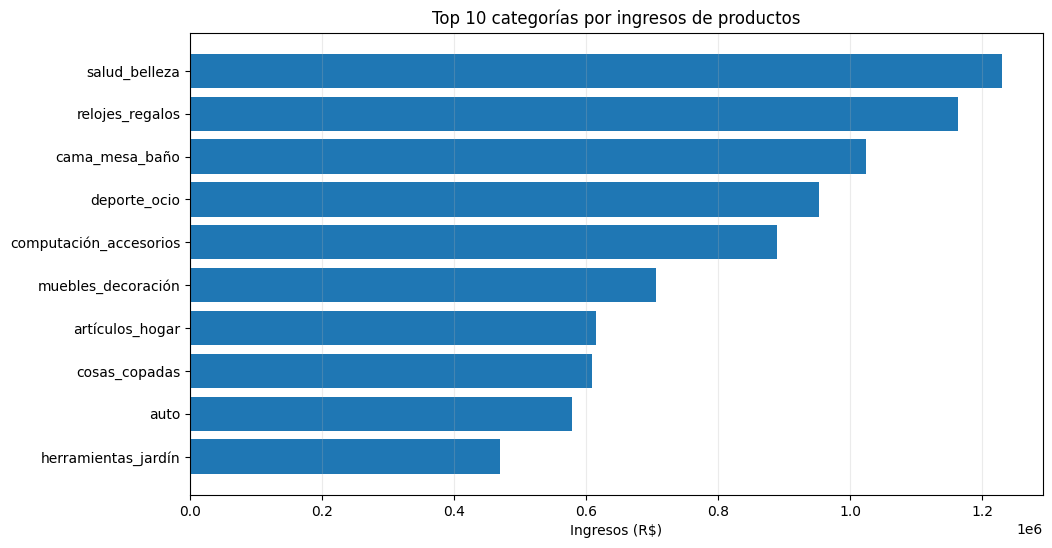

In [34]:
plt.figure(figsize=(11,6))
top10 = top_categorias.head(10).sort_values('ingresos')
plt.barh(top10['categoria'], top10['ingresos'])
plt.title('Top 10 categorías por ingresos de productos')
plt.xlabel('Ingresos (R$)')
plt.grid(axis='x', alpha=0.25)
plt.show()

**Conclusión:** las categorías con más ingresos no son necesariamente las que tienen más unidades. Por ejemplo, categorías de precio medio más alto pueden facturar mucho aunque vendan menos ítems. Esto muestra por qué conviene analizar ingresos, cantidad y ticket promedio en conjunto.

## 6. Ventas por día de la semana
Analizamos la probabilidad de que un pedido ocurra cada día. Esto sirve para detectar patrones de demanda.

In [35]:
ventas_dia = periodo.groupby(['dia_semana_num', 'dia_semana']).agg(
    pedidos=('order_id', 'count'),
    ingresos=('ingresos_productos', 'sum'),
    ticket_medio=('ingresos_productos', 'mean')
).reset_index().sort_values('dia_semana_num')
ventas_dia['P(pedido en ese día)'] = ventas_dia['pedidos'] / ventas_dia['pedidos'].sum()
ventas_dia

,dia_semana_num,dia_semana,pedidos,ingresos,ticket_medio,P(pedido en ese día)
0,0,Lunes,15660,"2,165,304.0600",138.2697,0.1628
1,1,Martes,15449,"2,113,668.6300",136.8159,0.1606
2,2,Miércoles,15041,"2,045,363.9400",135.9859,0.1563
3,3,Jueves,14281,"1,952,575.5600",136.7254,0.1484
4,4,Viernes,13646,"1,904,409.8700",139.5581,0.1418
5,5,Sábado,10519,"1,456,456.7100",138.4596,0.1093
6,6,Domingo,11615,"1,543,248.3600",132.8668,0.1207


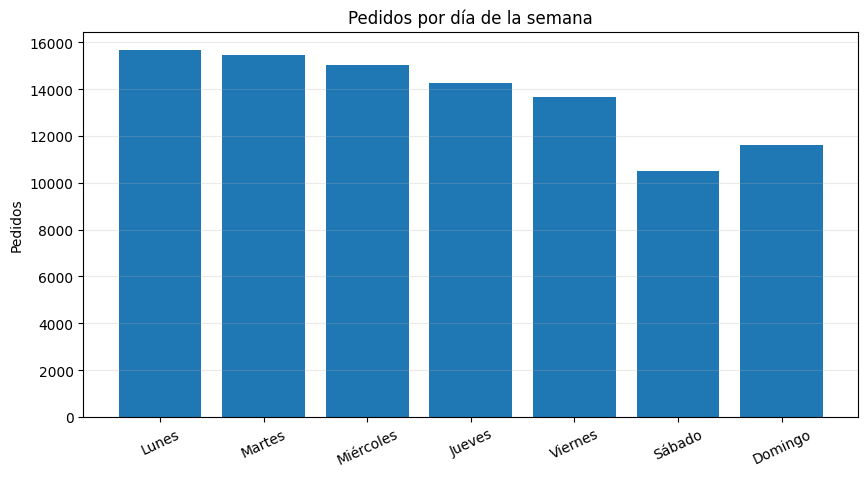

In [36]:
plt.figure(figsize=(10,5))
plt.bar(ventas_dia['dia_semana'], ventas_dia['pedidos'])
plt.title('Pedidos por día de la semana')
plt.ylabel('Pedidos')
plt.xticks(rotation=25)
plt.grid(axis='y', alpha=0.25)
plt.show()

**Conclusión:** los pedidos se concentran más entre lunes y miércoles. El fin de semana tiene menor volumen, especialmente sábado. Esto es lógico para e-commerce: muchos usuarios compran durante días laborales o retoman compras al inicio de la semana.

## 7. Evolución mensual
Observamos la tendencia temporal para ver crecimiento, estacionalidad o cambios en el volumen de ventas.

In [37]:
ventas_mensuales = periodo.groupby('mes').agg(
    pedidos=('order_id', 'count'),
    ingresos=('ingresos_productos', 'sum'),
    ticket_medio=('ingresos_productos', 'mean')
).reset_index()
ventas_mensuales.head()

,mes,pedidos,ingresos,ticket_medio
0,2017-01,750,"111,798.3600",149.0645
1,2017-02,1653,"234,223.4000",141.6959
2,2017-03,2546,"359,198.8500",141.0836
3,2017-04,2303,"340,669.6800",147.9243
4,2017-05,3546,"489,338.2500",137.9973


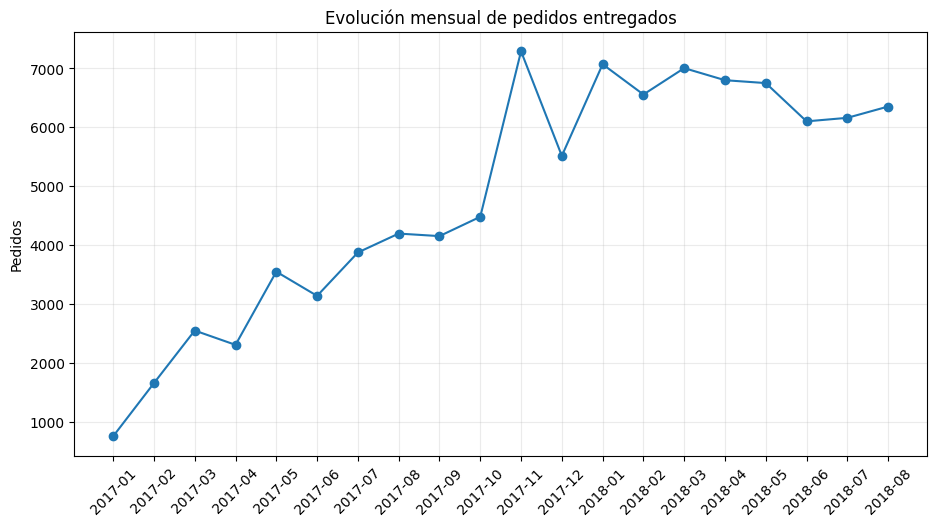

In [38]:
plt.figure(figsize=(11,5.5))
plt.plot(ventas_mensuales['mes'], ventas_mensuales['pedidos'], marker='o')
plt.title('Evolución mensual de pedidos entregados')
plt.ylabel('Pedidos')
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.show()

**Conclusión:** durante 2017 y 2018 se observa una base de actividad sostenida con meses de mayor volumen. Para un negocio real, esta gráfica sirve para decidir planificación de stock, atención al cliente y campañas de marketing.

## 8. Probabilidad simple
Calculamos probabilidades de compra por categoría.

In [39]:
prob_categorias = top_categorias[['categoria', 'pedidos', 'P(pedido con categoría)']].head(10)
prob_categorias

,categoria,pedidos,P(pedido con categoría)
0,salud_belleza,8610,0.0895
1,relojes_regalos,5491,0.0571
2,cama_mesa_baño,9267,0.0963
3,deporte_ocio,7513,0.0781
4,computación_accesorios,6518,0.0677
5,muebles_decoración,6258,0.0650
6,artículos_hogar,5734,0.0596
7,cosas_copadas,3552,0.0369
8,auto,3802,0.0395
9,herramientas_jardín,3443,0.0358


**Conclusión:** estas probabilidades permiten estimar qué tan común es que un pedido incluya una categoría. Sirven para comparar categorías no solo por facturación, sino también por frecuencia real en los pedidos.

## 9. Probabilidad condicional
Calculamos la probabilidad de que un pedido tenga más de un ítem dado que compró una categoría

In [40]:
# Precomputamos para que el cálculo sea rápido y claro.
item_counts_por_pedido = periodo.set_index('order_id')['cantidad_items']
n_categorias_por_pedido = items_periodo.groupby('order_id')['categoria'].nunique()

condicionales = []
for cat in top_categorias.head(12)['categoria']:
    pedidos_con_cat = set(items_periodo.loc[items_periodo['categoria'].eq(cat), 'order_id'])
    cantidad = len(pedidos_con_cat)
    p_item_adicional = item_counts_por_pedido.loc[list(pedidos_con_cat)].gt(1).mean()
    p_otra_categoria = n_categorias_por_pedido.loc[list(pedidos_con_cat)].gt(1).mean()
    condicionales.append({
        'categoría base': cat,
        'pedidos con categoría': cantidad,
        'P(más de un item | categoría)': p_item_adicional,
        'P(otra categoría | categoría)': p_otra_categoria
    })

prob_condicional = pd.DataFrame(condicionales).sort_values('P(más de un item | categoría)', ascending=False)
prob_condicional

,categoría base,pedidos con categoría,P(más de un item | categoría),P(otra categoría | categoría)
5,muebles_decoración,6258,0.2173,0.0323
9,herramientas_jardín,3443,0.1728,0.0206
2,cama_mesa_baño,9267,0.1547,0.0217
6,artículos_hogar,5734,0.1315,0.0202
4,computación_accesorios,6518,0.1197,0.0078
3,deporte_ocio,7513,0.1009,0.0096
0,salud_belleza,8610,0.0774,0.0082
11,bebé,2800,0.0746,0.0332
8,auto,3802,0.0713,0.0095
10,juguetes,3782,0.0603,0.0135


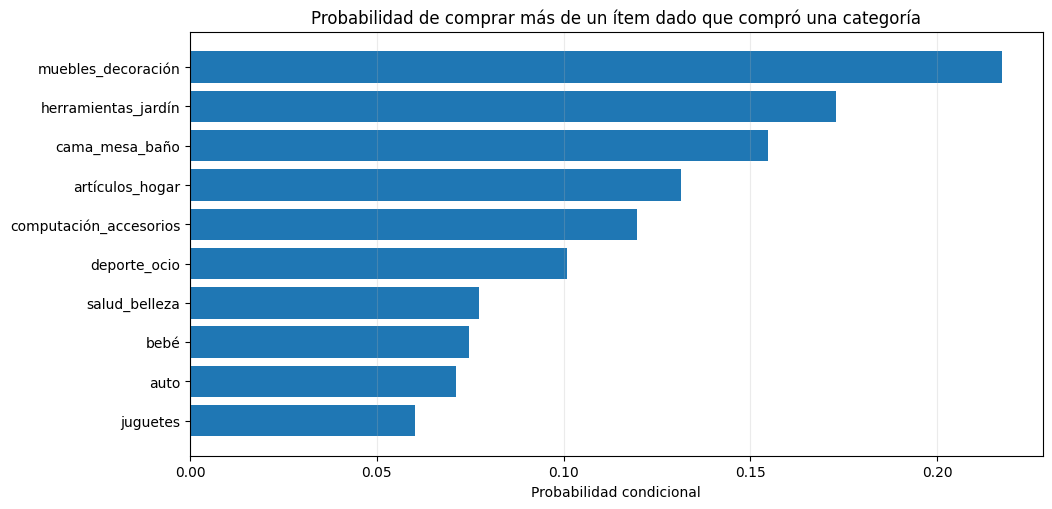

In [41]:
plt.figure(figsize=(11,5.5))
plot_cond = prob_condicional.head(10).sort_values('P(más de un item | categoría)')
plt.barh(plot_cond['categoría base'], plot_cond['P(más de un item | categoría)'])
plt.title('Probabilidad de comprar más de un ítem dado que compró una categoría')
plt.xlabel('Probabilidad condicional')
plt.grid(axis='x', alpha=0.25)
plt.show()

**Conclusión:** algunas categorías tienen mayor probabilidad de aparecer en pedidos con más de un ítem. Esto puede indicar compras complementarias o compras de varios productos similares. No significa causalidad, pero sí una oportunidad para recomendaciones o combos.

## 10. Probabilidad total aplicada a reseñas
Usamos la regla de probabilidad total para estimar la probabilidad de reseña positiva según si la entrega llegó tarde o a tiempo:

$P(Positiva)=P(Tarde)P(Positiva\mid Tarde)+P(A\ tiempo)P(Positiva\mid A\ tiempo)$

In [42]:
reviews_validas = order_values.dropna(subset=['review_score']).copy()
reviews_validas['positiva'] = reviews_validas['review_score'] >= 4

p_tarde = reviews_validas['entrega_tarde'].mean()
p_pos_tarde = reviews_validas.loc[reviews_validas['entrega_tarde'], 'positiva'].mean()
p_pos_tiempo = reviews_validas.loc[~reviews_validas['entrega_tarde'], 'positiva'].mean()
p_pos_total = p_tarde * p_pos_tarde + (1 - p_tarde) * p_pos_tiempo

pd.DataFrame({
    'concepto': ['P(entrega tarde)', 'P(reseña positiva | tarde)', 'P(reseña positiva | a tiempo)', 'P(reseña positiva) por probabilidad total', 'P(reseña positiva) observada'],
    'valor': [p_tarde, p_pos_tarde, p_pos_tiempo, p_pos_total, reviews_validas['positiva'].mean()]
})

,concepto,valor
0,P(entrega tarde),0.0799
1,P(reseña positiva | tarde),0.3456
2,P(reseña positiva | a tiempo),0.8277
3,P(reseña positiva) por probabilidad total,0.7892
4,P(reseña positiva) observada,0.7892


**Conclusión:** la probabilidad de reseña positiva baja mucho cuando la entrega llega tarde. Esto es consistente con la lógica del negocio: la experiencia de entrega impacta directamente en la satisfacción del cliente.

## 11. Modelo Normal: ingresos diarios
Probamos una aproximación normal para los ingresos diarios. La normal puede ser útil para estimar rangos esperados de facturación diaria, aunque siempre hay que mirar si el ajuste tiene sentido.

Media diaria: R$ 21,895.39
Desvío estándar diario: R$ 12,200.77
Percentil 95 estimado por Normal: R$ 41,963.87
P(ingresos diarios > R$100.000) según Normal: 0.00000000
KS statistic: 0.0548 - p-value: 0.0518


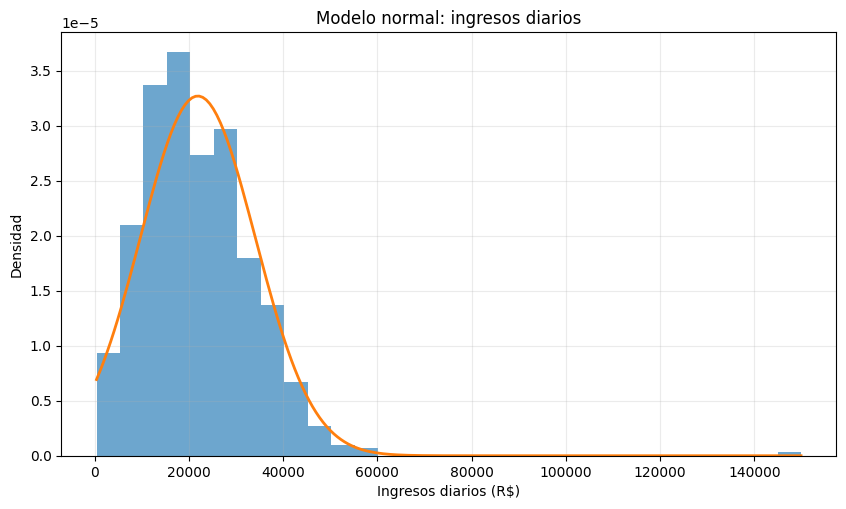

In [43]:
diario = periodo.set_index('fecha_compra').resample('D').agg(
    pedidos=('order_id', 'count'),
    ingresos=('ingresos_productos', 'sum')
).reset_index()

mu = diario['ingresos'].mean()
sigma = diario['ingresos'].std(ddof=1)
percentil_95 = stats.norm.ppf(0.95, mu, sigma)
p_mas_100k = 1 - stats.norm.cdf(100000, mu, sigma)
ks_norm = stats.kstest((diario['ingresos'] - mu) / sigma, 'norm')

print(f'Media diaria: R$ {mu:,.2f}')
print(f'Desvío estándar diario: R$ {sigma:,.2f}')
print(f'Percentil 95 estimado por Normal: R$ {percentil_95:,.2f}')
print(f'P(ingresos diarios > R$100.000) según Normal: {p_mas_100k:.8f}')
print(f'KS statistic: {ks_norm.statistic:.4f} - p-value: {ks_norm.pvalue:.4f}')

plt.figure(figsize=(10,5.5))
plt.hist(diario['ingresos'], bins=30, density=True, alpha=0.65)
x = np.linspace(diario['ingresos'].min(), diario['ingresos'].max(), 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2)
plt.title('Modelo normal: ingresos diarios')
plt.xlabel('Ingresos diarios (R$)')
plt.ylabel('Densidad')
plt.grid(alpha=0.25)
plt.show()

**Conclusión:** la normal aproxima razonablemente el centro de la distribución, pero no representa perfecto los extremos. En datos reales de ventas es común que existan días atípicos por promociones, estacionalidad o eventos comerciales.

## 12. Modelo de Poisson: pedidos por hora
El modelo de Poisson se usa para contar eventos en intervalos de tiempo. Aquí lo aplicamos a la cantidad de pedidos por hora.

Lambda promedio de pedidos por hora: 6.6679
Máximo observado de pedidos en una hora: 103
P(20 o más pedidos en una hora) según Poisson: 0.00002290


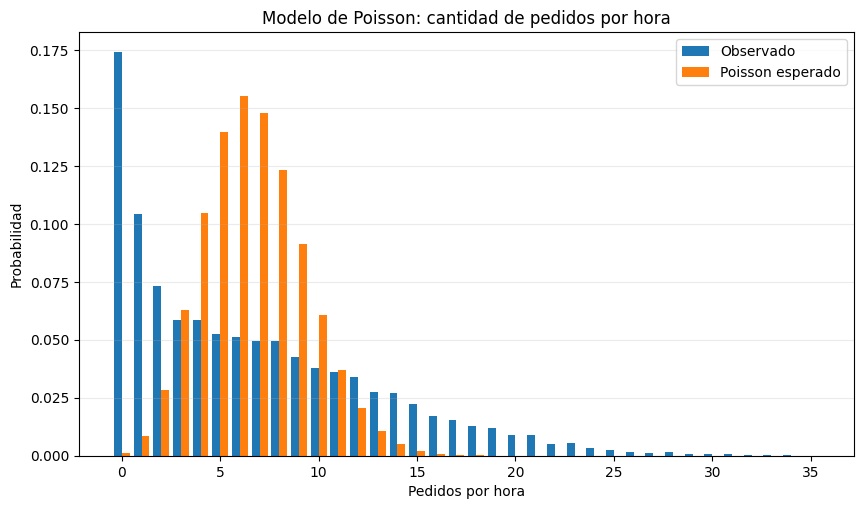

In [44]:
horario = periodo.set_index('fecha_compra').resample('h').agg(pedidos=('order_id', 'count')).reset_index()
lambda_hora = horario['pedidos'].mean()
p_20_o_mas = 1 - stats.poisson.cdf(19, lambda_hora)

print(f'Lambda promedio de pedidos por hora: {lambda_hora:.4f}')
print(f'Máximo observado de pedidos en una hora: {horario["pedidos"].max()}')
print(f'P(20 o más pedidos en una hora) según Poisson: {p_20_o_mas:.8f}')

conteos = horario['pedidos'].value_counts().sort_index()
max_k = min(max(conteos.index.max(), 20), 35)
ks = np.arange(0, max_k + 1)
obs = np.array([conteos.get(k, 0) for k in ks]) / len(horario)
esp = stats.poisson.pmf(ks, lambda_hora)

plt.figure(figsize=(10,5.5))
ancho = 0.4
plt.bar(ks - ancho/2, obs, width=ancho, label='Observado')
plt.bar(ks + ancho/2, esp, width=ancho, label='Poisson esperado')
plt.title('Modelo de Poisson: cantidad de pedidos por hora')
plt.xlabel('Pedidos por hora')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.show()

**Conclusión:** Poisson sirve como una primera aproximación para contar pedidos por hora, pero el máximo observado muestra que hay horas muy atípicas. En e-commerce real, los pedidos no llegan siempre de manera homogénea: influyen horarios, campañas, días especiales y hábitos de compra.

## 13. Modelo Binomial: reseñas positivas
Si tomamos una muestra de 10 pedidos y definimos “éxito” como reseña positiva, podemos modelar cuántas reseñas positivas aparecen con una binomial.

Probabilidad observada de reseña positiva: 0.7892
P(al menos 8 reseñas positivas en 10 pedidos): 0.6449


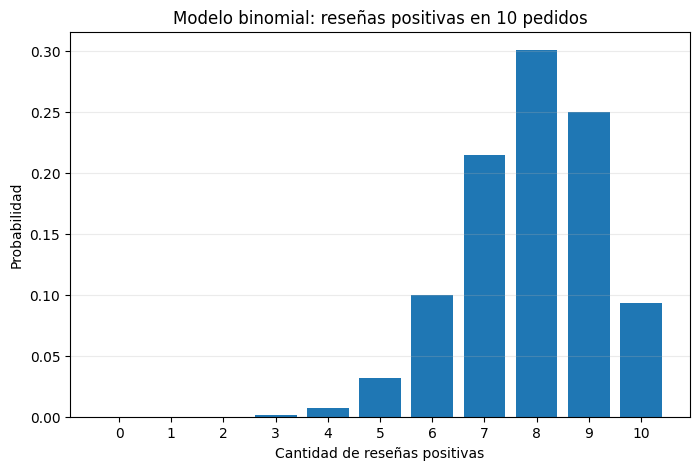

In [45]:
p_positiva = reviews_validas['positiva'].mean()
p_al_menos_8_de_10 = 1 - stats.binom.cdf(7, 10, p_positiva)

print(f'Probabilidad observada de reseña positiva: {p_positiva:.4f}')
print(f'P(al menos 8 reseñas positivas en 10 pedidos): {p_al_menos_8_de_10:.4f}')

valores = np.arange(0, 11)
probs = stats.binom.pmf(valores, 10, p_positiva)

plt.figure(figsize=(8,5))
plt.bar(valores, probs)
plt.title('Modelo binomial: reseñas positivas en 10 pedidos')
plt.xlabel('Cantidad de reseñas positivas')
plt.ylabel('Probabilidad')
plt.xticks(valores)
plt.grid(axis='y', alpha=0.25)
plt.show()

**Conclusión:** como la probabilidad observada de reseña positiva es alta, también es alta la probabilidad de que en 10 pedidos aparezcan 8 o más reseñas positivas. La binomial es útil cuando hay una cantidad fija de intentos y cada pedido se clasifica como éxito o no éxito.

In [46]:
# ============================================================
# Análisis adicional: pedidos problemáticos
# ============================================================

# Tomamos pedidos con información de entrega y reseña
riesgo = order_values.dropna(subset=['review_score']).copy()

# Definimos eventos
riesgo['llego_tarde'] = riesgo['entrega_tarde']
riesgo['resena_baja'] = riesgo['review_score'] <= 2

# Evento combinado: pedido problemático
riesgo['pedido_problematico'] = riesgo['llego_tarde'] | riesgo['resena_baja']

# Probabilidades
p_tarde = riesgo['llego_tarde'].mean()
p_resena_baja = riesgo['resena_baja'].mean()
p_tarde_y_baja = (riesgo['llego_tarde'] & riesgo['resena_baja']).mean()
p_problematico = riesgo['pedido_problematico'].mean()

print("P(entrega tarde):", round(p_tarde, 4))
print("P(reseña baja):", round(p_resena_baja, 4))
print("P(entrega tarde y reseña baja):", round(p_tarde_y_baja, 4))
print("P(pedido problemático):", round(p_problematico, 4))

P(entrega tarde): 0.0799
P(reseña baja): 0.1277
P(entrega tarde y reseña baja): 0.0432
P(pedido problemático): 0.1645


In [47]:
# ============================================================
# Estudio adicional: Segmentación por valor económico y riesgo
# ============================================================

# Partimos del dataframe principal de pedidos con valor, entrega y reseña
segmentacion = order_values.dropna(subset=['ingreso_total', 'review_score']).copy()

# Definimos pedido de alto valor:
# usamos el percentil 75, es decir, el 25% de pedidos más caros
umbral_alto_valor = segmentacion['ingreso_total'].quantile(0.75)

segmentacion['alto_valor'] = segmentacion['ingreso_total'] >= umbral_alto_valor

# Definimos mala experiencia:
# pedido que llegó tarde o tuvo reseña baja
segmentacion['resena_baja'] = segmentacion['review_score'] <= 2
segmentacion['mala_experiencia'] = segmentacion['entrega_tarde'] | segmentacion['resena_baja']

# Creamos segmentos de negocio
def clasificar_segmento(row):
    if row['alto_valor'] and row['mala_experiencia']:
        return 'Alto valor + mala experiencia'
    elif row['alto_valor'] and not row['mala_experiencia']:
        return 'Alto valor + buena experiencia'
    elif not row['alto_valor'] and row['mala_experiencia']:
        return 'Bajo/medio valor + mala experiencia'
    else:
        return 'Bajo/medio valor + buena experiencia'

segmentacion['segmento_negocio'] = segmentacion.apply(clasificar_segmento, axis=1)

# Resumen por segmento
tabla_segmentos = segmentacion.groupby('segmento_negocio').agg(
    cantidad_pedidos=('order_id', 'count'),
    ingreso_total=('ingreso_total', 'sum'),
    ticket_promedio=('ingreso_total', 'mean'),
    prob_resena_positiva=('review_score', lambda x: (x >= 4).mean()),
    prob_entrega_tarde=('entrega_tarde', 'mean')
).reset_index()

tabla_segmentos['porcentaje_pedidos'] = (
    tabla_segmentos['cantidad_pedidos'] / tabla_segmentos['cantidad_pedidos'].sum()
) * 100

tabla_segmentos['porcentaje_ingresos'] = (
    tabla_segmentos['ingreso_total'] / tabla_segmentos['ingreso_total'].sum()
) * 100

tabla_segmentos = tabla_segmentos.sort_values('ingreso_total', ascending=False)

tabla_segmentos

,segmento_negocio,cantidad_pedidos,ingreso_total,ticket_promedio,prob_resena_positiva,prob_entrega_tarde,porcentaje_pedidos,porcentaje_ingresos
0,Alto valor + buena experiencia,19267,"7,162,344.5100",371.7416,0.9127,0.0000,20.1050,46.8392
2,Bajo/medio valor + buena experiencia,60803,"5,262,307.2800",86.5468,0.9110,0.0000,63.4475,34.4136
1,Alto valor + mala experiencia,4699,"1,870,111.0100",397.9806,0.1390,0.4482,4.9034,12.2299
3,Bajo/medio valor + mala experiencia,11063,"996,590.5100",90.0832,0.1803,0.5021,11.5442,6.5173


In [48]:
# ============================================================
# Análisis geográfico del riesgo logístico
# ============================================================

# Recuperamos customer_id en la tabla riesgo para poder unir con clientes
geo_riesgo = riesgo.merge(orders[['order_id', 'customer_id']], on='order_id', how='left')

# Promediamos coordenadas por prefijo de código postal
geo_promedio = geolocation.groupby('geolocation_zip_code_prefix').agg(
    latitud=('geolocation_lat', 'mean'),
    longitud=('geolocation_lng', 'mean')
).reset_index()

# Incorporamos el código postal del cliente
geo_riesgo = geo_riesgo.merge(
    customers[['customer_id', 'customer_zip_code_prefix', 'customer_state']],
    on='customer_id',
    how='left'
)

# Incorporamos el seller_id desde order_items
seller_por_pedido = order_items.groupby('order_id')['seller_id'].first().reset_index()

geo_riesgo = geo_riesgo.merge(
    seller_por_pedido,
    on='order_id',
    how='left'
)

# Incorporamos el código postal del vendedor
geo_riesgo = geo_riesgo.merge(
    sellers[['seller_id', 'seller_zip_code_prefix', 'seller_state']],
    on='seller_id',
    how='left'
)

# Coordenadas del cliente
geo_riesgo = geo_riesgo.merge(
    geo_promedio.rename(columns={
        'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
        'latitud': 'lat_cliente',
        'longitud': 'lon_cliente'
    }),
    on='customer_zip_code_prefix',
    how='left'
)

# Coordenadas del vendedor
geo_riesgo = geo_riesgo.merge(
    geo_promedio.rename(columns={
        'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
        'latitud': 'lat_vendedor',
        'longitud': 'lon_vendedor'
    }),
    on='seller_zip_code_prefix',
    how='left'
)

# Eliminamos pedidos sin coordenadas
geo_riesgo = geo_riesgo.dropna(
    subset=['lat_cliente', 'lon_cliente', 'lat_vendedor', 'lon_vendedor']
).copy()

# Fórmula de Haversine para calcular distancia aproximada entre dos puntos geográficos
def calcular_distancia_km(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

geo_riesgo['distancia_km'] = calcular_distancia_km(
    geo_riesgo['lat_cliente'],
    geo_riesgo['lon_cliente'],
    geo_riesgo['lat_vendedor'],
    geo_riesgo['lon_vendedor']
)

# Dividimos los pedidos en 4 grupos según distancia
geo_riesgo['rango_distancia'] = pd.qcut(
    geo_riesgo['distancia_km'],
    q=4,
    labels=['Muy cerca', 'Cerca/intermedia', 'Lejos', 'Muy lejos']
)

# Tabla resumen
tabla_geo_riesgo = geo_riesgo.groupby('rango_distancia').agg(
    cantidad_pedidos=('order_id', 'count'),
    distancia_promedio_km=('distancia_km', 'mean'),
    prob_pedido_problematico=('pedido_problematico', 'mean'),
    prob_entrega_tarde=('llego_tarde', 'mean'),
    prob_resena_baja=('resena_baja', 'mean')
).reset_index()

# Pasamos probabilidades a porcentaje
tabla_geo_riesgo['prob_pedido_problematico'] = tabla_geo_riesgo['prob_pedido_problematico'] * 100
tabla_geo_riesgo['prob_entrega_tarde'] = tabla_geo_riesgo['prob_entrega_tarde'] * 100
tabla_geo_riesgo['prob_resena_baja'] = tabla_geo_riesgo['prob_resena_baja'] * 100

tabla_geo_riesgo = tabla_geo_riesgo.round(2)

display(tabla_geo_riesgo)

,rango_distancia,cantidad_pedidos,distancia_promedio_km,prob_pedido_problematico,prob_entrega_tarde,prob_resena_baja
0,Muy cerca,23839,64.9700,13.8800,6.2300,10.1600
1,Cerca/intermedia,23841,327.2100,16.1000,7.2700,13.0000
2,Lejos,23836,582.5800,16.8900,8.2400,13.3500
3,Muy lejos,23839,"1,426.8100",18.9200,10.1900,14.5900


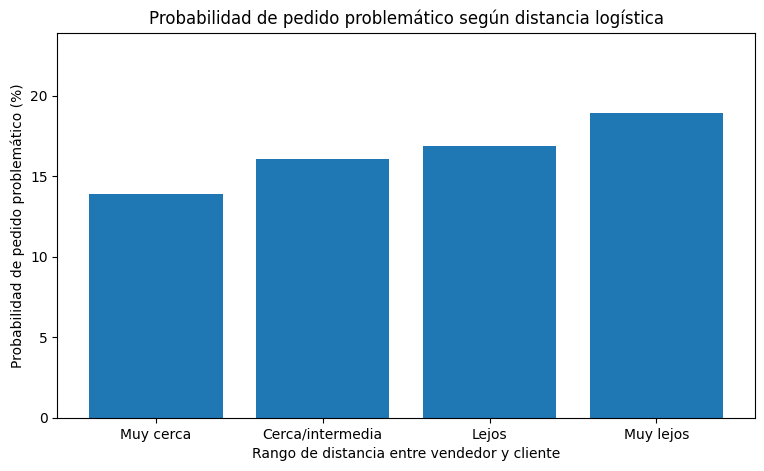

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.bar(
    tabla_geo_riesgo['rango_distancia'],
    tabla_geo_riesgo['prob_pedido_problematico']
)

plt.title('Probabilidad de pedido problemático según distancia logística')
plt.xlabel('Rango de distancia entre vendedor y cliente')
plt.ylabel('Probabilidad de pedido problemático (%)')
plt.ylim(0, tabla_geo_riesgo['prob_pedido_problematico'].max() + 5)
plt.show()

In [50]:
print("Cantidad de pedidos analizados con geolocalización:", len(geo_riesgo))
print("Distancia promedio general:", round(geo_riesgo['distancia_km'].mean(), 2), "km")
display(tabla_geo_riesgo)


Cantidad de pedidos analizados con geolocalización: 95355
Distancia promedio general: 600.39 km


,rango_distancia,cantidad_pedidos,distancia_promedio_km,prob_pedido_problematico,prob_entrega_tarde,prob_resena_baja
0,Muy cerca,23839,64.9700,13.8800,6.2300,10.1600
1,Cerca/intermedia,23841,327.2100,16.1000,7.2700,13.0000
2,Lejos,23836,582.5800,16.8900,8.2400,13.3500
3,Muy lejos,23839,"1,426.8100",18.9200,10.1900,14.5900


In [51]:
# ============================================================
# Análisis geográfico adicional: zonas reales por estado del cliente
# ============================================================

riesgo_estado = geo_riesgo.groupby('customer_state').agg(
    cantidad_pedidos=('order_id', 'count'),
    distancia_promedio_km=('distancia_km', 'mean'),
    prob_pedido_problematico=('pedido_problematico', 'mean'),
    prob_entrega_tarde=('llego_tarde', 'mean'),
    prob_resena_baja=('resena_baja', 'mean')
).reset_index()

# Pasamos probabilidades a porcentaje
riesgo_estado['prob_pedido_problematico'] *= 100
riesgo_estado['prob_entrega_tarde'] *= 100
riesgo_estado['prob_resena_baja'] *= 100

# Redondeamos
riesgo_estado = riesgo_estado.round(2)

# Filtramos estados con al menos 300 pedidos para evitar conclusiones por pocos datos
riesgo_estado_filtrado = riesgo_estado[
    riesgo_estado['cantidad_pedidos'] >= 300
].copy()

# Ordenamos por mayor probabilidad de pedido problemático
riesgo_estado_filtrado = riesgo_estado_filtrado.sort_values(
    'prob_pedido_problematico',
    ascending=False
)

display(riesgo_estado_filtrado.head(10))

,customer_state,cantidad_pedidos,distancia_promedio_km,prob_pedido_problematico,prob_entrega_tarde,prob_resena_baja
1,AL,393,"1,833.3100",30.2800,23.4100,21.1200
9,MA,708,"2,101.9700",27.6800,19.0700,19.6300
24,SE,333,"1,649.4600",23.7200,15.0200,18.9200
4,BA,3211,"1,343.9500",23.3300,13.6100,17.1000
16,PI,468,"1,955.8700",22.8600,15.8100,16.2400
5,CE,1266,"2,184.6900",22.7500,15.3200,17.1400
18,RJ,12161,488.5300,22.7100,13.2900,18.3100
13,PA,931,"2,292.9700",21.9100,11.9200,17.9400
7,ES,1958,803.9200,19.6100,11.7500,13.8400
14,PB,506,"2,087.3600",19.5700,10.8700,15.0200


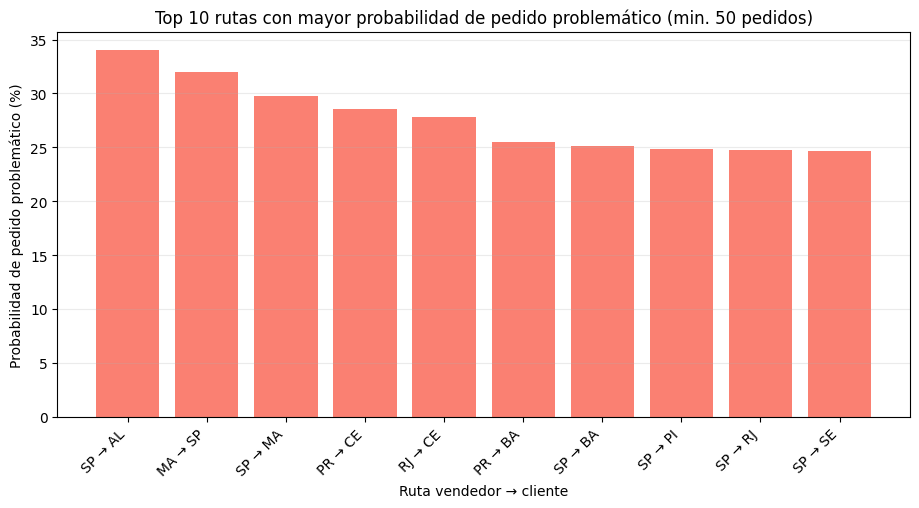

In [53]:
# Calculamos el riesgo por ruta (Estado Vendedor -> Estado Cliente)
geo_riesgo['ruta_estado'] = geo_riesgo['seller_state'] + ' → ' + geo_riesgo['customer_state']

riesgo_rutas = geo_riesgo.groupby('ruta_estado').agg(
    cantidad_pedidos=('order_id', 'count'),
    prob_pedido_problematico=('pedido_problematico', 'mean')
).reset_index()

# Convertimos a porcentaje y filtramos rutas con volumen representativo
riesgo_rutas['prob_pedido_problematico'] *= 100
riesgo_rutas_filtrado = riesgo_rutas[riesgo_rutas['cantidad_pedidos'] >= 50].sort_values('prob_pedido_problematico', ascending=False)

# Graficamos
plt.figure(figsize=(11,5))
top_rutas = riesgo_rutas_filtrado.head(10)

plt.bar(
    top_rutas['ruta_estado'],
    top_rutas['prob_pedido_problematico'],
    color='salmon'
)

plt.title('Top 10 rutas con mayor probabilidad de pedido problemático (min. 50 pedidos)')
plt.xlabel('Ruta vendedor → cliente')
plt.ylabel('Probabilidad de pedido problemático (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.show()

In [55]:
# ============================================================
# Análisis geográfico adicional: categorías más vendidas por estado
# ============================================================

# Base con pedidos, clientes, items y categorías
# Corregimos el merge para asegurar que traemos customer_id
productos_zona = order_items.drop(columns=['customer_id'], errors='ignore').merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)

productos_zona = productos_zona.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

productos_zona = productos_zona.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

productos_zona = productos_zona.merge(
    translation[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left'
)

# Usamos la categoría traducida si existe; si no, usamos la original
productos_zona['categoria'] = productos_zona['product_category_name_english'].fillna(
    productos_zona['product_category_name']
)

# Resumen por estado y categoría
categorias_estado = productos_zona.groupby(
    ['customer_state', 'categoria']
).agg(
    cantidad_items=('order_item_id', 'count'),
    ingresos=('price', 'sum'),
    precio_promedio=('price', 'mean')
).reset_index()

# Categoría con más ingresos por estado
idx_top_ingresos = categorias_estado.groupby('customer_state')['ingresos'].idxmax()
top_categoria_por_estado = categorias_estado.loc[idx_top_ingresos].copy()

top_categoria_por_estado = top_categoria_por_estado.sort_values(
    'ingresos',
    ascending=False
)

display(top_categoria_por_estado.head(15))

,customer_state,categoria,cantidad_items,ingresos,precio_promedio
1259,SP,bed_bath_table,5157,"472,238.0700",91.5722
977,RJ,watches_gifts,846,"174,895.0100",206.7317
508,MG,health_beauty,1064,"154,324.1500",145.0415
1086,RS,bed_bath_table,611,"60,040.9500",98.2667
902,PR,sports_leisure,476,"57,653.3000",121.1204
164,BA,health_beauty,340,"49,955.1200",146.9268
1206,SC,sports_leisure,356,"41,579.0300",116.7950
773,PE,health_beauty,233,"40,685.0100",174.6138
300,DF,watches_gifts,146,"32,292.2700",221.1799
219,CE,health_beauty,162,"31,544.5000",194.7191


In [57]:
# ============================================================
# Categorías más vendidas por estado usando nombres ya traducidos del TP
# ============================================================

# Eliminamos customer_id si ya existe para evitar duplicados (.drop)
productos_zona = order_items.drop(columns=['customer_id'], errors='ignore').merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)

productos_zona = productos_zona.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

productos_zona = productos_zona.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

productos_zona = productos_zona.merge(
    translation[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left'
)

productos_zona['categoria'] = productos_zona['product_category_name_english'].fillna(
    productos_zona['product_category_name']
)

categorias_estado = productos_zona.groupby(
    ['customer_state', 'categoria']
).agg(
    cantidad_items=('order_item_id', 'count'),
    ingresos=('price', 'sum'),
    precio_promedio=('price', 'mean')
).reset_index()

# Top 3 categorías por estado según ingresos
top3_categorias_estado = categorias_estado.sort_values(
    ['customer_state', 'ingresos'],
    ascending=[True, False]
).groupby('customer_state').head(3)

display(top3_categorias_estado.head(30))

,customer_state,categoria,cantidad_items,ingresos,precio_promedio
22,AC,sports_leisure,9,"1,677.4600",186.3844
26,AC,watches_gifts,4,"1,389.6000",347.4000
15,AC,health_beauty,7,"1,386.5800",198.0829
50,AL,health_beauty,62,"12,681.2600",204.5365
68,AL,watches_gifts,35,"11,605.0200",331.5720
35,AL,computers_accessories,39,"7,605.6100",195.0156
88,AM,health_beauty,20,"2,776.0300",138.8015
87,AM,garden_tools,5,"1,980.8800",396.1760
77,AM,computers_accessories,16,"1,815.7400",113.4838
111,AP,computers_accessories,8,"2,050.0300",256.2537


In [58]:
# ============================================================
# Categorías principales en estados con mayor riesgo problemático
# ============================================================

estados_mayor_riesgo = riesgo_estado_filtrado.head(6)['customer_state'].tolist()

categorias_estados_riesgo = categorias_estado[
    categorias_estado['customer_state'].isin(estados_mayor_riesgo)
].copy()

top_categorias_estados_riesgo = categorias_estados_riesgo.sort_values(
    ['customer_state', 'ingresos'],
    ascending=[True, False]
).groupby('customer_state').head(5)

display(top_categorias_estados_riesgo)

,customer_state,categoria,cantidad_items,ingresos,precio_promedio
50,AL,health_beauty,62,"12,681.2600",204.5365
68,AL,watches_gifts,35,"11,605.0200",331.5720
35,AL,computers_accessories,39,"7,605.6100",195.0156
30,AL,auto,22,"4,578.5400",208.1155
66,AL,telephony,27,"4,434.1600",164.2281
164,BA,health_beauty,340,"49,955.1200",146.9268
188,BA,watches_gifts,225,"45,631.5200",202.8068
183,BA,sports_leisure,286,"37,010.0600",129.4058
140,BA,computers_accessories,250,"32,635.8300",130.5433
131,BA,auto,155,"29,112.7100",187.8239


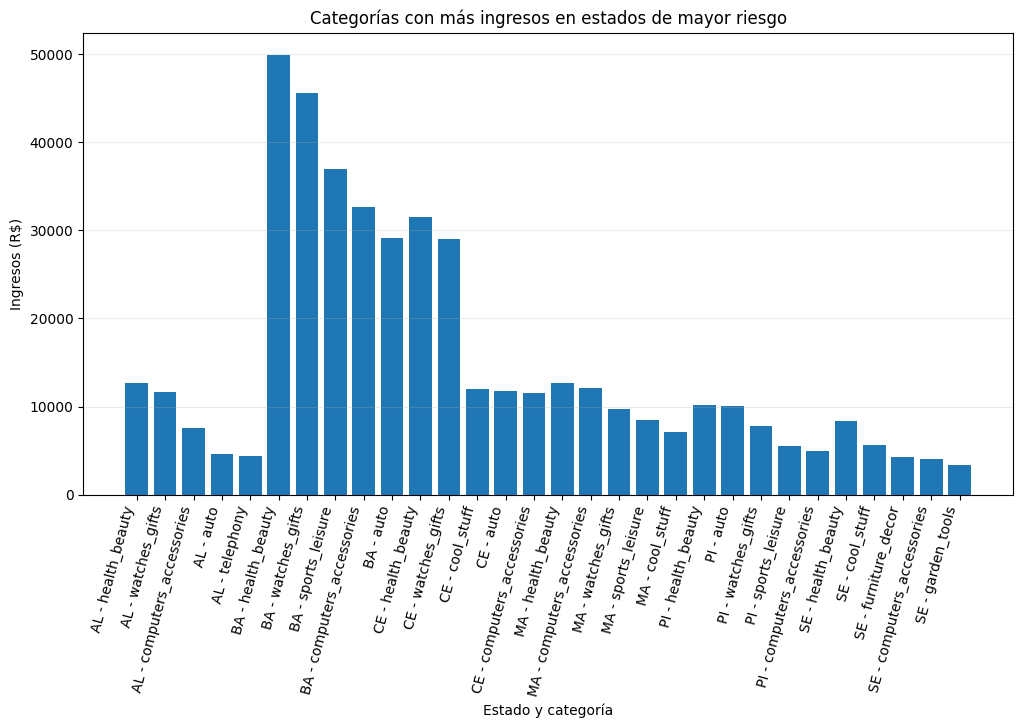

In [60]:
plt.figure(figsize=(12,6))

datos_plot = top_categorias_estados_riesgo.copy()
datos_plot['estado_categoria'] = datos_plot['customer_state'] + ' - ' + datos_plot['categoria']

plt.bar(
    datos_plot['estado_categoria'],
    datos_plot['ingresos']
)

plt.title('Categorías con más ingresos en estados de mayor riesgo')
plt.xlabel('Estado y categoría')
plt.ylabel('Ingresos (R$)')
plt.xticks(rotation=75, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.show()